In [1]:
# ============================================================
# NOTEBOOK 06
# Modified-gravity ringdown templates on pyRing baseline
# BLOCK 1
#
# What this block does:
# 1. Imports packages
# 2. Loads the saved GR baseline from Notebook 05
# 3. Rebuilds the minimal physics helpers we need
# 4. Defines a GR Kerr-QNM-based multimode waveform generator
#
# Why we do this:
# - pyRing gave us the GR baseline template
# - for modified gravity, we now want explicit control over
#   mode-by-mode frequency, damping, amplitude, and phase shifts
# - the cleanest way is:
#       pyRing baseline for GR
#       custom deformation layer for MG
# ============================================================

import warnings
from dataclasses import dataclass, asdict

import numpy as np
import matplotlib.pyplot as plt
import qnm

warnings.filterwarnings("ignore", category=np.exceptions.VisibleDeprecationWarning)

# Physical constants
G = 6.67430e-11
C = 299_792_458.0
MSUN = 1.988409870698051e30

# Plotting defaults
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# ------------------------------------------------------------
# Load the GR baseline saved from Notebook 05
# ------------------------------------------------------------
baseline = np.load("pyring_gr_ringdown_templates.npz")

times = baseline["times"]
hp_kerrbh = baseline["kerrbh_hplus"]
hc_kerrbh = baseline["kerrbh_hcross"]
hp_mmrdns_multi = baseline["mmrdns_multi_hplus"]
hc_mmrdns_multi = baseline["mmrdns_multi_hcross"]

dt = times[1] - times[0]
duration = times[-1] + dt
fs = 1.0 / dt

print("Loaded GR baseline file.")
print("times shape:", times.shape)
print("KerrBH h_plus shape:", hp_kerrbh.shape)
print("MMRDNS h_plus shape:", hp_mmrdns_multi.shape)
print("duration =", duration)
print("sample_rate =", fs)

# ------------------------------------------------------------
# Minimal Kerr remnant container
# ------------------------------------------------------------
@dataclass
class KerrRemnant:
    mass_msun: float
    chi: float

    def __post_init__(self):
        if self.mass_msun <= 0:
            raise ValueError("mass_msun must be positive")
        if not (-1.0 < self.chi < 1.0):
            raise ValueError("chi must satisfy -1 < chi < 1")

    @property
    def mass_si(self) -> float:
        return self.mass_msun * MSUN

    @property
    def time_unit(self) -> float:
        return G * self.mass_si / C**3


# ------------------------------------------------------------
# Kerr QNM lookup using qnm
#
# We use qnm here because we want explicit access to the
# underlying mode frequencies and damping rates so we can
# deform them directly.
# ------------------------------------------------------------
def get_kerr_qnm(remnant: KerrRemnant, l: int, m: int, n: int, s: int = -2) -> dict:
    mode_seq = qnm.modes_cache(s=s, l=l, m=m, n=n)
    omega = mode_seq(a=remnant.chi)[0]

    omega_r_geom = float(np.real(omega))
    omega_i_geom = float(-np.imag(omega))   # qnm returns omega_R - i omega_I

    M_sec = remnant.time_unit
    omega_r_si = omega_r_geom / M_sec
    omega_i_si = omega_i_geom / M_sec

    return {
        "l": l,
        "m": m,
        "n": n,
        "omega_complex_geom": omega,
        "omega_r_geom": omega_r_geom,
        "omega_i_geom": omega_i_geom,
        "omega_r_si": omega_r_si,
        "omega_i_si": omega_i_si,
        "f_hz": omega_r_si / (2.0 * np.pi),
        "tau_s": 1.0 / omega_i_si,
    }


# ------------------------------------------------------------
# Data structures for explicit multimode waveform construction
# ------------------------------------------------------------
@dataclass
class RingdownMode:
    l: int
    m: int
    n: int
    amplitude: float
    phase: float


@dataclass
class RingdownSignal:
    t: np.ndarray
    h_complex: np.ndarray

    @property
    def h_plus(self) -> np.ndarray:
        return np.real(self.h_complex)

    @property
    def h_cross(self) -> np.ndarray:
        return -np.imag(self.h_complex)


# ------------------------------------------------------------
# Low-level damped-sinusoid builder from physical frequencies
# ------------------------------------------------------------
def component_strain_from_freqs(
    amplitude: float,
    phase: float,
    omega_r_si: float,
    omega_i_si: float,
    t: np.ndarray,
    t0: float = 0.0,
) -> np.ndarray:
    dt_local = t - t0
    mask = dt_local >= 0.0

    h = np.zeros_like(t, dtype=np.complex128)
    h[mask] = (
        amplitude
        * np.exp(-omega_i_si * dt_local[mask])
        * np.exp(-1j * (omega_r_si * dt_local[mask] + phase))
    )
    return h


# ------------------------------------------------------------
# GR multimode ringdown builder
#
# This is our explicit, controllable GR reference model.
# ------------------------------------------------------------
def generate_gr_ringdown(
    remnant: KerrRemnant,
    modes: list[RingdownMode],
    t: np.ndarray,
    t0: float = 0.0,
    s: int = -2,
) -> RingdownSignal:
    h = np.zeros_like(t, dtype=np.complex128)

    for mode in modes:
        q = get_kerr_qnm(remnant, mode.l, mode.m, mode.n, s=s)
        h += component_strain_from_freqs(
            amplitude=mode.amplitude,
            phase=mode.phase,
            omega_r_si=q["omega_r_si"],
            omega_i_si=q["omega_i_si"],
            t=t,
            t0=t0,
        )

    return RingdownSignal(t=t, h_complex=h)

/home/omer/venvs/class/lib/python3.12/site-packages/qnm/schwarzschild/tabulated.py:163: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  loaded = pickle.load(handle)
/home/omer/venvs/class/lib/python3.12/site-packages/qnm/schwarzschild/tabulated.py:169: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  loaded = pickle.load(handle, encoding='latin1')


Loaded GR baseline file.
times shape: (410,)
KerrBH h_plus shape: (410,)
MMRDNS h_plus shape: (410,)
duration = 0.050048828125
sample_rate = 8192.0


In [2]:
# ============================================================
# BLOCK 2
#
# What this block does:
# 1. Defines the modified-gravity deformation container
# 2. Defines helpers for per-mode deviations
# 3. Builds a modified-gravity waveform from the GR spectrum
#
# Deformation model:
# For each mode we allow:
#   - fractional frequency shift
#   - fractional damping-time shift
#   - fractional amplitude shift
#   - additive phase shift
#
# The damping-time deformation is implemented through:
#   tau -> tau * (1 + d_tau_frac)
# which implies
#   omega_I -> omega_I / (1 + d_tau_frac)
# ============================================================

@dataclass
class ModeDeviation:
    d_omega_frac: float = 0.0
    d_tau_frac: float = 0.0
    d_amp_frac: float = 0.0
    d_phase: float = 0.0


def get_mode_deviation(
    deviations: dict[tuple[int, int, int], ModeDeviation],
    l: int,
    m: int,
    n: int,
) -> ModeDeviation:
    return deviations.get((l, m, n), ModeDeviation())


def deform_qnm_physical_parameters(
    omega_r_si: float,
    omega_i_si: float,
    deviation: ModeDeviation,
) -> tuple[float, float]:
    if 1.0 + deviation.d_tau_frac <= 0.0:
        raise ValueError("d_tau_frac must satisfy 1 + d_tau_frac > 0")

    omega_r_new = omega_r_si * (1.0 + deviation.d_omega_frac)
    omega_i_new = omega_i_si / (1.0 + deviation.d_tau_frac)

    return omega_r_new, omega_i_new


def generate_modified_ringdown(
    remnant: KerrRemnant,
    modes: list[RingdownMode],
    deviations: dict[tuple[int, int, int], ModeDeviation],
    t: np.ndarray,
    t0: float = 0.0,
    s: int = -2,
) -> RingdownSignal:
    h = np.zeros_like(t, dtype=np.complex128)

    for mode in modes:
        q = get_kerr_qnm(remnant, mode.l, mode.m, mode.n, s=s)
        dev = get_mode_deviation(deviations, mode.l, mode.m, mode.n)

        omega_r_new, omega_i_new = deform_qnm_physical_parameters(
            q["omega_r_si"],
            q["omega_i_si"],
            dev,
        )

        amp_new = mode.amplitude * (1.0 + dev.d_amp_frac)
        phase_new = mode.phase + dev.d_phase

        h += component_strain_from_freqs(
            amplitude=amp_new,
            phase=phase_new,
            omega_r_si=omega_r_new,
            omega_i_si=omega_i_new,
            t=t,
            t0=t0,
        )

    return RingdownSignal(t=t, h_complex=h)

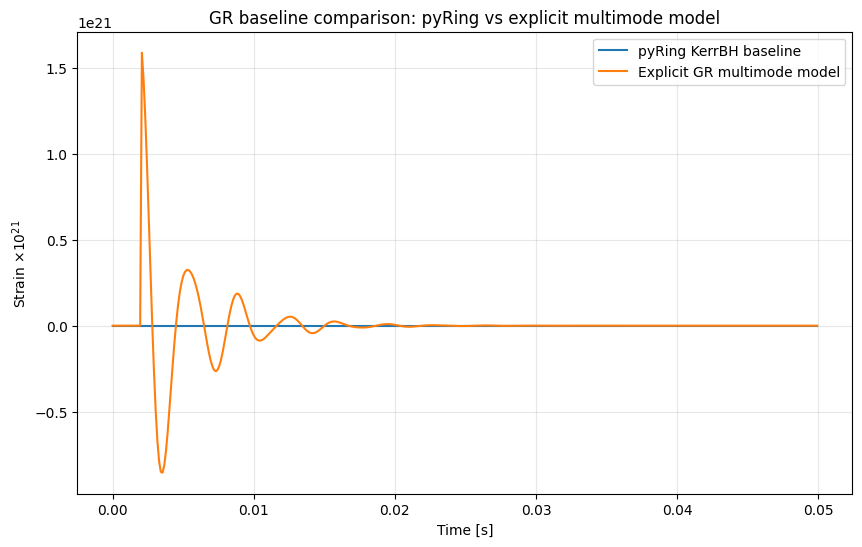

Built GR and MG explicit ringdown signals.
GR max |h|: 1.6076149728512328
MG max |h|: 1.5898115458508135


In [3]:
# ============================================================
# BLOCK 3
#
# What this block does:
# 1. Defines a fiducial remnant and explicit mode content
# 2. Builds the GR waveform from the explicit mode model
# 3. Compares it to the loaded pyRing KerrBH baseline
# 4. Defines one example modified-gravity deformation model
# 5. Builds the MG waveform
#
# Important note:
# The explicit GR waveform here is not meant to reproduce pyRing
# sample-by-sample exactly. It is a controllable multimode model
# built from Kerr QNM frequencies and user-chosen amplitudes/phases.
#
# The pyRing KerrBH waveform remains our baseline reference.
# ============================================================

# Fiducial remnant chosen to match the pyRing baseline setup
remnant = KerrRemnant(mass_msun=60.0, chi=0.7)
t0 = 0.002

# Explicit mode content chosen to mirror the earlier KerrBH test
modes = [
    RingdownMode(l=2, m=2, n=0, amplitude=1.00, phase=0.00),
    RingdownMode(l=2, m=2, n=1, amplitude=0.45, phase=0.30),
    RingdownMode(l=3, m=3, n=0, amplitude=0.25, phase=-0.50),
]

# Build explicit GR waveform
signal_gr = generate_gr_ringdown(
    remnant=remnant,
    modes=modes,
    t=times,
    t0=t0,
)

# Compare explicit GR model to loaded pyRing KerrBH baseline
scale = 1e21

plt.figure()
plt.plot(times, scale * hp_kerrbh, label="pyRing KerrBH baseline")
plt.plot(times, scale * signal_gr.h_plus, label="Explicit GR multimode model")
plt.xlabel("Time [s]")
plt.ylabel(r"Strain $\times 10^{21}$")
plt.title("GR baseline comparison: pyRing vs explicit multimode model")
plt.legend()
plt.show()

# Example mode-dependent modified-gravity deformation model
deviations = {
    (2, 2, 0): ModeDeviation(d_omega_frac=0.02,  d_tau_frac=0.10, d_amp_frac=0.00, d_phase=0.00),
    (2, 2, 1): ModeDeviation(d_omega_frac=-0.01, d_tau_frac=0.15, d_amp_frac=0.05, d_phase=0.10),
    (3, 3, 0): ModeDeviation(d_omega_frac=0.03,  d_tau_frac=-0.05, d_amp_frac=-0.10, d_phase=-0.08),
}

signal_mg = generate_modified_ringdown(
    remnant=remnant,
    modes=modes,
    deviations=deviations,
    t=times,
    t0=t0,
)

print("Built GR and MG explicit ringdown signals.")
print("GR max |h|:", np.max(np.abs(signal_gr.h_complex)))
print("MG max |h|:", np.max(np.abs(signal_mg.h_complex)))